# HAM10000 — 3 Model Ensemble (EfficientNet-B0 + YOLOv8n-cls + Mask R-CNN)

**Amaç:** 3 modelin test seti üzerindeki olasılık çıktılarını (`probabilities_*.npy`) **soft voting** ile birleştirip ensemble performansını ölçmek ve tek tek modellerle karşılaştırmak.

**Girdiler (her modelden):**
- `probabilities_<model>.npy` → shape `(1497, 7)`, satır toplamı ≈ 1
- `test_labels_<model>.npy`   → shape `(1497,)`, integer 0–6

3 modelin de test split'i aynı (seed=42, lesion-based stratified) olduğu için `test_labels_*.npy` dosyaları birebir aynı sırada. Notebook bunu doğruluyor.

**Çıktılar:**
- Soft voting ensemble: accuracy + macro F1
- 3 model + ensemble karşılaştırma tablosu
- Sınıf bazında precision / recall / F1
- Confusion matrix (ensemble)
- Sınıf bazında recall heatmap (4 yöntem yan yana)

In [1]:
# ============================================================
# 0. GOOGLE DRIVE'I MOUNT ET
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# 1. KÜTÜPHANELER
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    recall_score,
)

print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


In [3]:
# ============================================================
# 2. AYARLAR
# ============================================================
# 6 npy dosyasını Drive'da bir klasöre koy. Klasör yolunu burada güncelle.
#
# Önerilen yapı:
#   /content/drive/MyDrive/cilt_kanseri_ensemble/
#       ├── probabilities_efficientnet_b0.npy
#       ├── test_labels_efficientnet_b0.npy
#       ├── probabilities_yolov8n_cls.npy
#       ├── test_labels_yolov8n_cls.npy
#       ├── probabilities_maskrcnn.npy
#       └── test_labels_maskrcnn.npy

DRIVE_DIR  = '/content/drive/MyDrive/cilt_kanseri_ensemble'
OUTPUT_DIR = '/content/output_ensemble'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 7 sınıf (HAM10000) — 3 modelde de aynı sıra
TARGET_CLASSES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
CLASS_FULL_NAMES = {
    'akiec': 'Actinic Keratoses',
    'bcc':   'Basal Cell Carcinoma',
    'bkl':   'Benign Keratosis',
    'df':    'Dermatofibroma',
    'mel':   'Melanoma',
    'nv':    'Melanocytic Nevi',
    'vasc':  'Vascular Lesions',
}
NUM_CLASSES = len(TARGET_CLASSES)

# Model dosya isimleri (her notebook'tan kaydedilen npy'ler)
MODEL_FILES = {
    'EfficientNet-B0': {
        'probs':  os.path.join(DRIVE_DIR, 'probabilities_efficientnet_b0.npy'),
        'labels': os.path.join(DRIVE_DIR, 'test_labels_efficientnet_b0.npy'),
    },
    'YOLOv8n-cls': {
        'probs':  os.path.join(DRIVE_DIR, 'probabilities_yolov8n_cls.npy'),
        'labels': os.path.join(DRIVE_DIR, 'test_labels_yolov8n_cls.npy'),
    },
    'Mask R-CNN': {
        'probs':  os.path.join(DRIVE_DIR, 'probabilities_maskrcnn.npy'),
        'labels': os.path.join(DRIVE_DIR, 'test_labels_maskrcnn.npy'),
    },
}

print(f'Sınıf sayısı: {NUM_CLASSES}')
print(f'Model sayısı: {len(MODEL_FILES)}')
print(f'Drive dizini: {DRIVE_DIR}')
print(f'Çıktı dizini: {OUTPUT_DIR}')

Sınıf sayısı: 7
Model sayısı: 3
Drive dizini: /content/drive/MyDrive/cilt_kanseri_ensemble
Çıktı dizini: /content/output_ensemble


In [4]:
# ============================================================
# 3. NPY DOSYALARINI YÜKLE + TUTARLILIK KONTROLÜ
# ============================================================
# 3 modelin de aynı seed + aynı lesion-based split kullandığı için
# test_labels dosyaları BİREBİR AYNI olmalı. Bunu zorunlu kılıyoruz.
# Ayrıca probability matrislerinin satır toplamlarının ~1 olduğunu da kontrol ediyoruz.

model_probs  = {}   # {model_name: np.ndarray (N, 7)}
model_labels = {}   # {model_name: np.ndarray (N,)}

for name, paths in MODEL_FILES.items():
    assert os.path.exists(paths['probs']),  f'BULUNAMADI: {paths["probs"]}'
    assert os.path.exists(paths['labels']), f'BULUNAMADI: {paths["labels"]}'
    p = np.load(paths['probs'])
    l = np.load(paths['labels'])
    model_probs[name]  = p
    model_labels[name] = l
    rowsum_mean = p.sum(axis=1).mean()
    print(f'{name:18s} | probs: {p.shape} | labels: {l.shape} | satır toplamı ort: {rowsum_mean:.4f}')

# --- Doğrulama 1: Probability shape'leri aynı mı?
shapes = {n: p.shape for n, p in model_probs.items()}
ref_shape = list(shapes.values())[0]
assert all(s == ref_shape for s in shapes.values()), f'Probability shape uyumsuz: {shapes}'
assert ref_shape[1] == NUM_CLASSES, f'Sınıf sayısı {ref_shape[1]}, beklenen {NUM_CLASSES}'

# --- Doğrulama 2: Tüm modellerin test_labels'ı birebir aynı mı?
ref_name, ref_labels = next(iter(model_labels.items()))
for name, lbl in model_labels.items():
    same = np.array_equal(lbl, ref_labels)
    print(f'  {name:18s} labels == {ref_name}? {same}')
    assert same, f'HATA: {name} test_labels {ref_name} ile farklı! Aynı split olmalı.'

# Tek bir y_true'yu referans olarak alıyoruz
y_true = ref_labels.astype(int)
N = len(y_true)
print(f'\nTüm doğrulamalar OK. Test örneği: {N}, sınıf: {NUM_CLASSES}')

EfficientNet-B0    | probs: (1497, 7) | labels: (1497,) | satır toplamı ort: 1.0000
YOLOv8n-cls        | probs: (1497, 7) | labels: (1497,) | satır toplamı ort: 1.0000
Mask R-CNN         | probs: (1497, 7) | labels: (1497,) | satır toplamı ort: 1.0000
  EfficientNet-B0    labels == EfficientNet-B0? True
  YOLOv8n-cls        labels == EfficientNet-B0? True
  Mask R-CNN         labels == EfficientNet-B0? True

Tüm doğrulamalar OK. Test örneği: 1497, sınıf: 7


In [5]:
# ============================================================
# 4. SOFT VOTING ENSEMBLE
# ============================================================
# Soft voting: 3 modelin sınıf olasılıklarının ARİTMETİK ORTALAMASI.
# Daha sonra argmax → ensemble tahmini.
#
# Eşit ağırlık (1/3, 1/3, 1/3) tercih edildi çünkü:
# - 3 modelin test F1'leri yakın (0.55–0.59)
# - Sınıf bazında her biri farklı sınıflarda lider → tamamlayıcı hatalar
# - Eşit ağırlık + lider değişimi birbirini en doğal şekilde tamamlar
# (Ağırlıklı versiyonu istenirse aşağıdaki weights array'i değiştirilebilir.)

model_names = list(model_probs.keys())
stacked = np.stack([model_probs[n] for n in model_names], axis=0)  # (3, N, 7)
weights = np.array([1/3, 1/3, 1/3])  # eşit ağırlık
ensemble_probs = np.tensordot(weights, stacked, axes=([0], [0]))   # (N, 7)
ensemble_preds = np.argmax(ensemble_probs, axis=1)

print(f'Ensemble probabilities shape: {ensemble_probs.shape}')
print(f'Satır toplamı ortalaması: {ensemble_probs.sum(axis=1).mean():.4f}  (1.0 olmalı)')
print(f'Tahmin shape: {ensemble_preds.shape}')

Ensemble probabilities shape: (1497, 7)
Satır toplamı ortalaması: 1.0000  (1.0 olmalı)
Tahmin shape: (1497,)


In [6]:
# ============================================================
# 5. 3 MODEL + ENSEMBLE KARŞILAŞTIRMA TABLOSU
# ============================================================
# Her yöntem için: Accuracy, Macro F1, Weighted F1

rows = []
for name in model_names:
    preds = np.argmax(model_probs[name], axis=1)
    rows.append({
        'Model':         name,
        'Accuracy':      accuracy_score(y_true, preds),
        'F1 (macro)':    f1_score(y_true, preds, average='macro'),
        'F1 (weighted)': f1_score(y_true, preds, average='weighted'),
    })

rows.append({
    'Model':         'ENSEMBLE (soft voting)',
    'Accuracy':      accuracy_score(y_true, ensemble_preds),
    'F1 (macro)':    f1_score(y_true, ensemble_preds, average='macro'),
    'F1 (weighted)': f1_score(y_true, ensemble_preds, average='weighted'),
})

comparison_df = pd.DataFrame(rows)
for col in ['Accuracy', 'F1 (macro)', 'F1 (weighted)']:
    comparison_df[col] = comparison_df[col].round(4)

print('=' * 70)
print('MODEL KARŞILAŞTIRMA')
print('=' * 70)
print(comparison_df.to_string(index=False))
print()

# Ensemble - en iyi tek model farkı
best_single_f1  = comparison_df.iloc[:-1]['F1 (macro)'].max()
best_single_acc = comparison_df.iloc[:-1]['Accuracy'].max()
ens_f1  = comparison_df.iloc[-1]['F1 (macro)']
ens_acc = comparison_df.iloc[-1]['Accuracy']
print(f'Ensemble F1 farkı  (en iyi tek modele göre): {ens_f1 - best_single_f1:+.4f}')
print(f'Ensemble Acc farkı (en iyi tek modele göre): {ens_acc - best_single_acc:+.4f}')

# CSV olarak kaydet
csv_path = os.path.join(OUTPUT_DIR, 'ensemble_comparison.csv')
comparison_df.to_csv(csv_path, index=False)
print(f'\nKaydedildi: {csv_path}')

MODEL KARŞILAŞTIRMA
                 Model  Accuracy  F1 (macro)  F1 (weighted)
       EfficientNet-B0    0.7615      0.5740         0.7695
           YOLOv8n-cls    0.7969      0.5710         0.7907
            Mask R-CNN    0.7782      0.5458         0.7675
ENSEMBLE (soft voting)    0.8223      0.6430         0.8169

Ensemble F1 farkı  (en iyi tek modele göre): +0.0690
Ensemble Acc farkı (en iyi tek modele göre): +0.0254

Kaydedildi: /content/output_ensemble/ensemble_comparison.csv


In [7]:
# ============================================================
# 6. ENSEMBLE — SINIF BAZINDA PRECISION / RECALL / F1
# ============================================================
print('=' * 70)
print('ENSEMBLE — Classification Report')
print('=' * 70)
print(classification_report(
    y_true, ensemble_preds,
    target_names=TARGET_CLASSES,
    digits=4,
    zero_division=0,
))

ENSEMBLE — Classification Report
              precision    recall  f1-score   support

       akiec     0.6176    0.4118    0.4941        51
         bcc     0.7027    0.6753    0.6887        77
         bkl     0.6024    0.6369    0.6192       157
          df     0.6000    0.2727    0.3750        22
         mel     0.6538    0.6071    0.6296       168
          nv     0.8974    0.9360    0.9163      1000
        vasc     1.0000    0.6364    0.7778        22

    accuracy                         0.8223      1497
   macro avg     0.7249    0.5966    0.6430      1497
weighted avg     0.8167    0.8223    0.8169      1497



Sınıf bazında recall:
       EfficientNet-B0  YOLOv8n-cls  Mask R-CNN  Ensemble
akiec            0.471        0.196       0.471     0.412
bcc              0.610        0.481       0.675     0.675
bkl              0.567        0.726       0.510     0.637
df               0.364        0.273       0.091     0.273
mel              0.595        0.589       0.464     0.607
nv               0.857        0.916       0.916     0.936
vasc             0.682        0.500       0.591     0.636



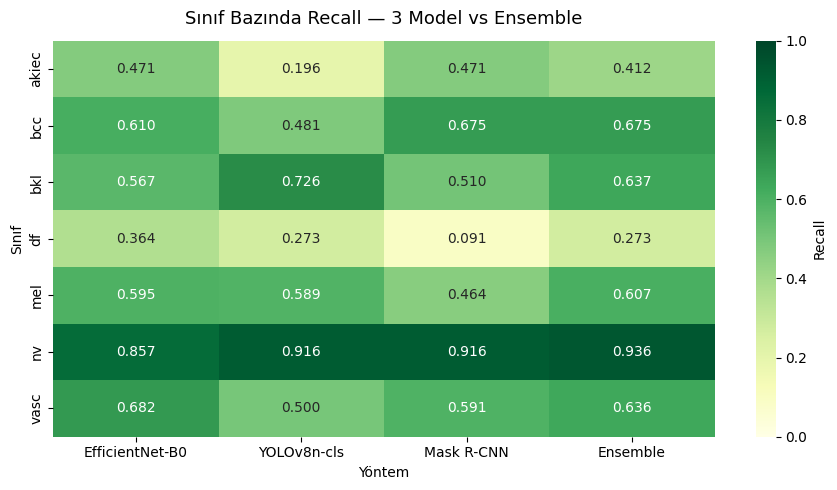

Kaydedildi: /content/output_ensemble/recall_heatmap_ensemble.png


In [8]:
# ============================================================
# 7. SINIF BAZINDA RECALL HEATMAP (3 model + ensemble)
# ============================================================
# Her sınıfta hangi yöntemin lider olduğunu net göstermek için.
# Promptta paylaşılan tabloyu programatik olarak yeniden üretip ensemble'ı ekliyoruz.

method_names = model_names + ['Ensemble']
all_preds = {n: np.argmax(model_probs[n], axis=1) for n in model_names}
all_preds['Ensemble'] = ensemble_preds

recall_matrix = []
for cls_idx, cls_name in enumerate(TARGET_CLASSES):
    row = []
    for m in method_names:
        r = recall_score(y_true == cls_idx, all_preds[m] == cls_idx, zero_division=0)
        row.append(r)
    recall_matrix.append(row)

recall_df = pd.DataFrame(recall_matrix, index=TARGET_CLASSES, columns=method_names)
print('Sınıf bazında recall:')
print(recall_df.round(3).to_string())
print()

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    recall_df, annot=True, fmt='.3f', cmap='YlGn',
    vmin=0, vmax=1, cbar_kws={'label': 'Recall'}, ax=ax,
)
ax.set_title('Sınıf Bazında Recall — 3 Model vs Ensemble', fontsize=13, pad=12)
ax.set_xlabel('Yöntem')
ax.set_ylabel('Sınıf')
plt.tight_layout()
heatmap_path = os.path.join(OUTPUT_DIR, 'recall_heatmap_ensemble.png')
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Kaydedildi: {heatmap_path}')

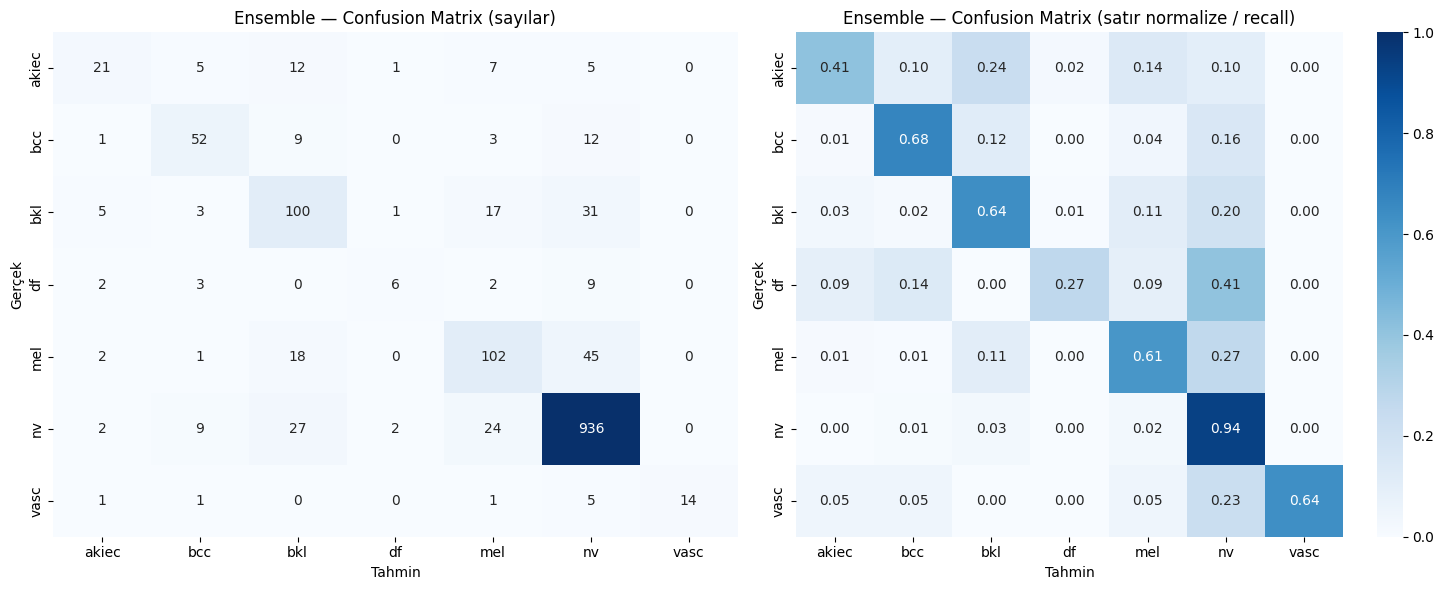

Kaydedildi: /content/output_ensemble/confusion_matrix_ensemble.png


In [9]:
# ============================================================
# 8. ENSEMBLE — CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, ensemble_preds, labels=range(NUM_CLASSES))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # satır normalize (recall görünümü)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Sol: ham sayılar
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES,
    ax=axes[0], cbar=False,
)
axes[0].set_title('Ensemble — Confusion Matrix (sayılar)')
axes[0].set_xlabel('Tahmin')
axes[0].set_ylabel('Gerçek')

# Sağ: satır-normalize
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES,
    ax=axes[1], vmin=0, vmax=1,
)
axes[1].set_title('Ensemble — Confusion Matrix (satır normalize / recall)')
axes[1].set_xlabel('Tahmin')
axes[1].set_ylabel('Gerçek')

plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, 'confusion_matrix_ensemble.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Kaydedildi: {cm_path}')

In [10]:
# ============================================================
# 9. ENSEMBLE OLASILIKLARINI KAYDET (raporda/sunumda lazım olabilir)
# ============================================================
import shutil

ens_probs_path  = os.path.join(OUTPUT_DIR, 'probabilities_ensemble.npy')
ens_preds_path  = os.path.join(OUTPUT_DIR, 'predictions_ensemble.npy')
ens_labels_path = os.path.join(OUTPUT_DIR, 'test_labels_ensemble.npy')

np.save(ens_probs_path,  ensemble_probs)
np.save(ens_preds_path,  ensemble_preds)
np.save(ens_labels_path, y_true)

print(f'Ensemble probs : {ens_probs_path}  | shape: {ensemble_probs.shape}')
print(f'Ensemble preds : {ens_preds_path}  | shape: {ensemble_preds.shape}')
print(f'Test labels    : {ens_labels_path} | shape: {y_true.shape}')

# Drive'a da kopyala (kalıcı saklama)
drive_backup = os.path.join(DRIVE_DIR, 'output_ensemble')
os.makedirs(drive_backup, exist_ok=True)
if os.path.realpath(OUTPUT_DIR) == os.path.realpath(drive_backup):
    print('OUTPUT_DIR zaten Drive\'da — ekstra kopya atlandı.')
else:
    for f in os.listdir(OUTPUT_DIR):
        src = os.path.join(OUTPUT_DIR, f)
        dst = os.path.join(drive_backup, f)
        if os.path.realpath(src) != os.path.realpath(dst):
            shutil.copy2(src, dst)
    print(f'\nTüm çıktılar Drive\'a yedeklendi: {drive_backup}')

Ensemble probs : /content/output_ensemble/probabilities_ensemble.npy  | shape: (1497, 7)
Ensemble preds : /content/output_ensemble/predictions_ensemble.npy  | shape: (1497,)
Test labels    : /content/output_ensemble/test_labels_ensemble.npy | shape: (1497,)

Tüm çıktılar Drive'a yedeklendi: /content/drive/MyDrive/cilt_kanseri_ensemble/output_ensemble


In [11]:
# ============================================================
# 10. ÖZET
# ============================================================
print('=' * 70)
print('ENSEMBLE PROJESİ TAMAMLANDI')
print('=' * 70)
print(f'Veri seti        : HAM10000 (test set: {N} örnek, {NUM_CLASSES} sınıf)')
print(f'Yöntem           : Soft Voting (eşit ağırlık 1/3-1/3-1/3)')
print(f'Birleştirilen    : EfficientNet-B0 + YOLOv8n-cls + Mask R-CNN')
print()
print('SONUÇLAR:')
print(comparison_df.to_string(index=False))
print()
print(f'Ensemble Accuracy : {ens_acc:.4f}')
print(f'Ensemble F1 macro : {ens_f1:.4f}')
print(f'En iyi tek modele göre F1 farkı : {ens_f1 - best_single_f1:+.4f}')
print()
print(f'Çıktı dizini: {OUTPUT_DIR}')
print(f'Drive yedek : {drive_backup}')

ENSEMBLE PROJESİ TAMAMLANDI
Veri seti        : HAM10000 (test set: 1497 örnek, 7 sınıf)
Yöntem           : Soft Voting (eşit ağırlık 1/3-1/3-1/3)
Birleştirilen    : EfficientNet-B0 + YOLOv8n-cls + Mask R-CNN

SONUÇLAR:
                 Model  Accuracy  F1 (macro)  F1 (weighted)
       EfficientNet-B0    0.7615      0.5740         0.7695
           YOLOv8n-cls    0.7969      0.5710         0.7907
            Mask R-CNN    0.7782      0.5458         0.7675
ENSEMBLE (soft voting)    0.8223      0.6430         0.8169

Ensemble Accuracy : 0.8223
Ensemble F1 macro : 0.6430
En iyi tek modele göre F1 farkı : +0.0690

Çıktı dizini: /content/output_ensemble
Drive yedek : /content/drive/MyDrive/cilt_kanseri_ensemble/output_ensemble
